In [15]:
import numpy as np

# position and velocity update function (only apply field then z<zmax)
def coordinate_update(v, r, dt, dBdx=-100, gamma = 2e3, m = 9.11e-31, zmax = 0.2) : 
    q = -1.6e-19 # electron
    if r[2] < zmax :
        B = np.array([0,dBdx*r[0],0])        
    else :
        B = np.array([0,0,0])
    F = q*np.cross(v,B)
    v1 = F*dt/(m*gamma) + v
    r1 = F*dt**2/(2*m*gamma) + v*dt + r
    return r1, v1

# calculate an orbit for initial position r and velocity v for nstep steps. 
def orbit(r, v, nstep=100) :
    rarray = []
    varray = [] 
    
    for i in range(nstep) : 
        rarray.append(r)
        varray.append(v)
        r, v = coordinate_update(v,r, 1e-11)
    
    rarray = np.array(rarray)
    varray = np.array(varray)  

    return rarray, varray

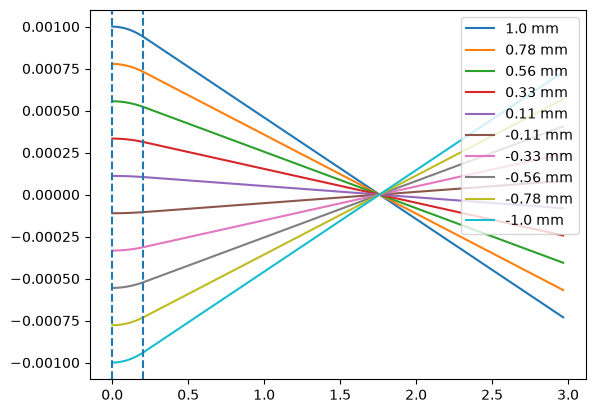

In [16]:
import matplotlib.pyplot as plt

for x in np.linspace(1e-3, -1e-3, 10) :
    rarray, varray = orbit(np.array([ x,0,0]), np.array([0,0,2.99792458e9]), 100)
    plt.plot(rarray[:,2], rarray[:,0],"-", label=str(round(x/1e-3,2))+" mm")
plt.axvline(0.0, linestyle="--")
plt.axvline(0.2, linestyle="--")
plt.legend(loc=1)